# Ch5 Lecture 4

# *SVD on matrices of data*

Applying the SVD to tabular data; interpreting $U$ and $V$; the
outer-product sum.

------------------------------------------------------------------------

## *Example: Height and weight*

$$
A^T=
\begin{bmatrix}
2.9 & -1.5 & 0.1 & -1.0 & 2.1 & -4.0 & -2.0 & 2.2 & 0.2 & 2.0 & 1.5 & -2.5 \\
4.0 & -0.9 & 0.0 & -1.0 & 3.0 & -5.0 & -3.5 & 2.6 & 1.0 & 3.5 & 1.0 & -4.7
\end{bmatrix}
$$

Each **column** represents one person:

$$
\begin{bmatrix}
\text{height} \\
\text{weight}
\end{bmatrix}.
$$

-   Rows = measurements (height, weight)
-   Columns = individuals

------------------------------------------------------------------------

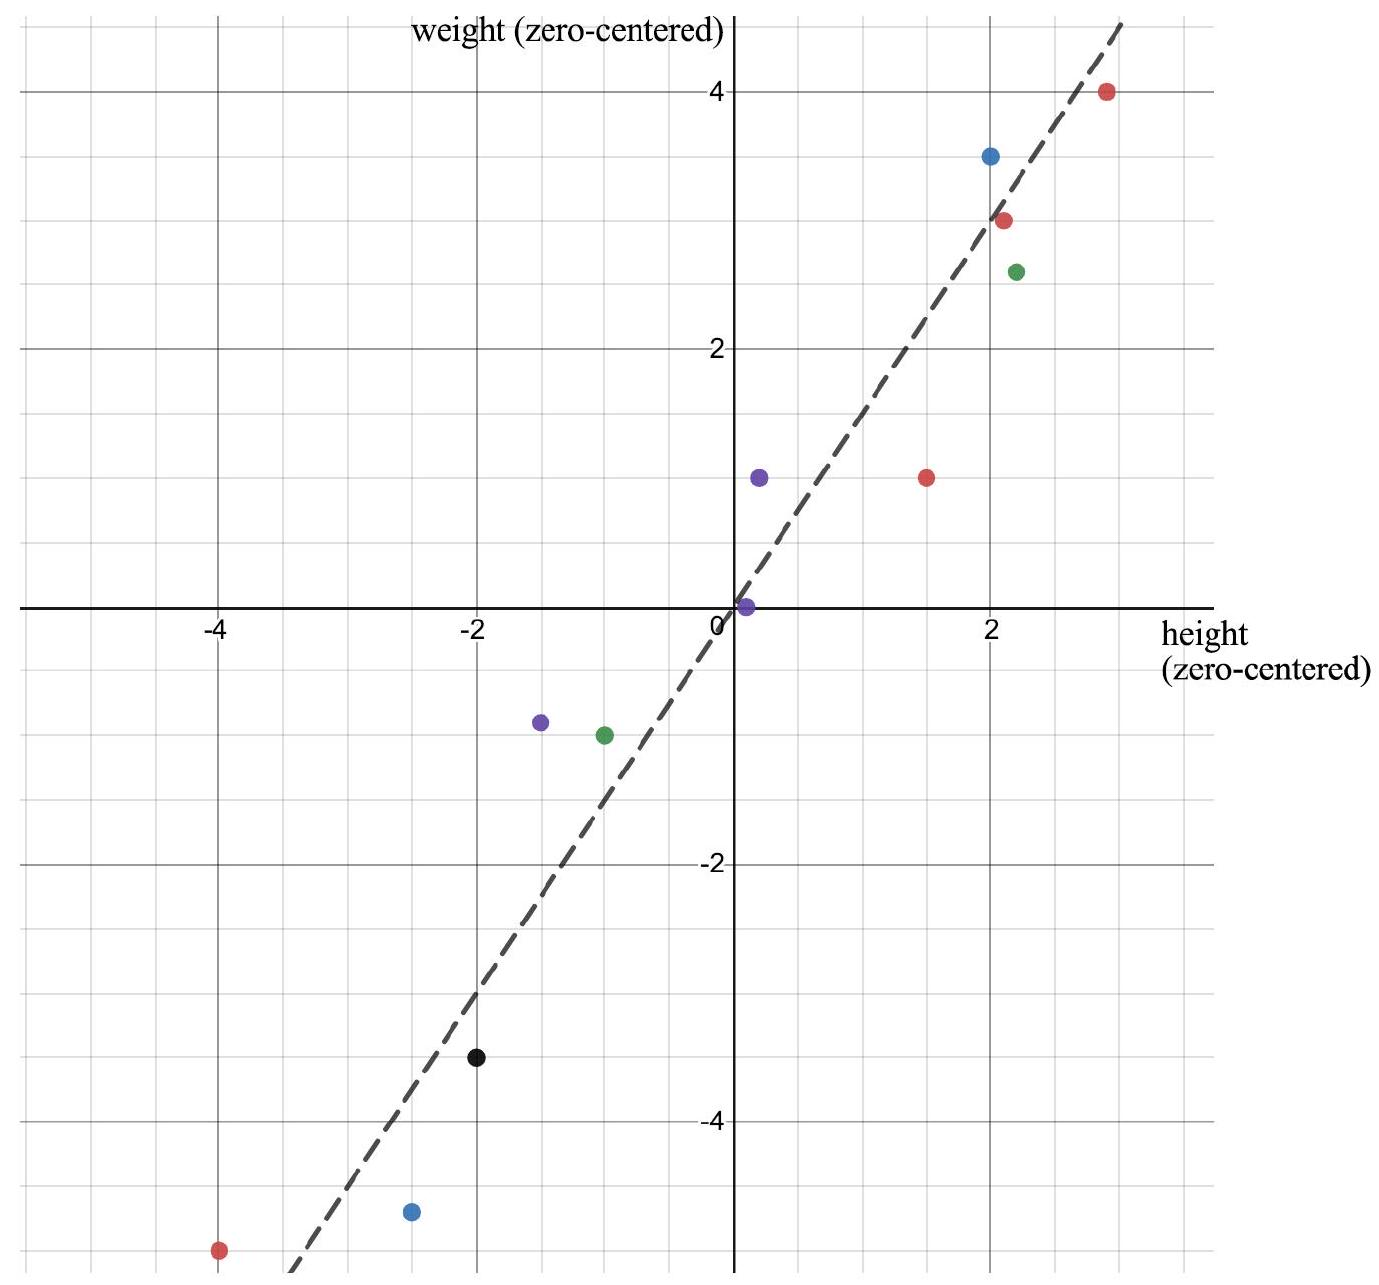

------------------------------------------------------------------------

## *Plotting*

<Figure size 672x480 with 0 Axes>

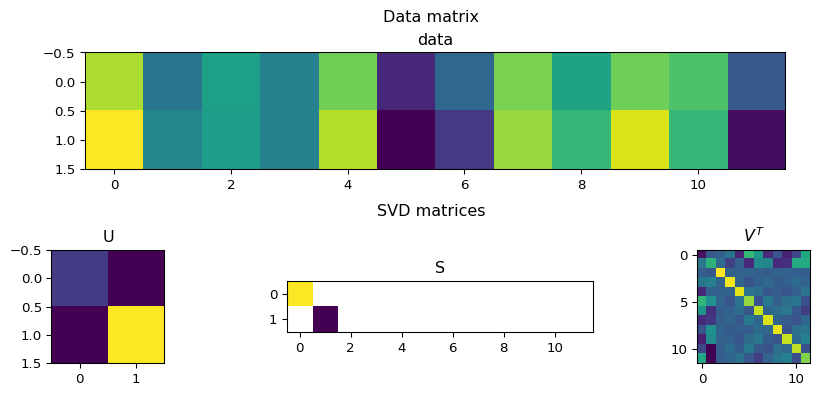

------------------------------------------------------------------------

## *The matrix $U$: directions among variables*

The columns of $U$ live in **height–weight space**.

Each column $u_i$ is a direction that can be drawn directly on the
scatterplot.

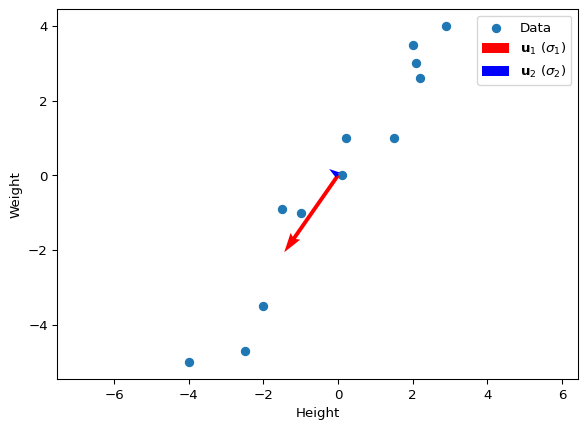

In [3]:
plt.clf()

plt.scatter(data.T[:,0], data.T[:,1], label='Data')
plt.quiver(0, 0, Ud[0,0]*Sd[0,0]/5, Ud[1,0]*Sd[0,0]/5, angles='xy', scale_units='xy', scale=1, color='red', label=r'$\mathbf{u}_1$ ($\sigma_1$)')
plt.quiver(0, 0, Ud[0,1]*Sd[1,1]/5, Ud[1,1]*Sd[1,1]/5, angles='xy', scale_units='xy', scale=1, color='blue', label=r'$\mathbf{u}_2$ ($\sigma_2$)')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.axis('equal')
plt.legend()
plt.show()

Each vector $u_i$ answers:

> **If the data vary according to one underlying pattern, how do the
> measurements change?**

##

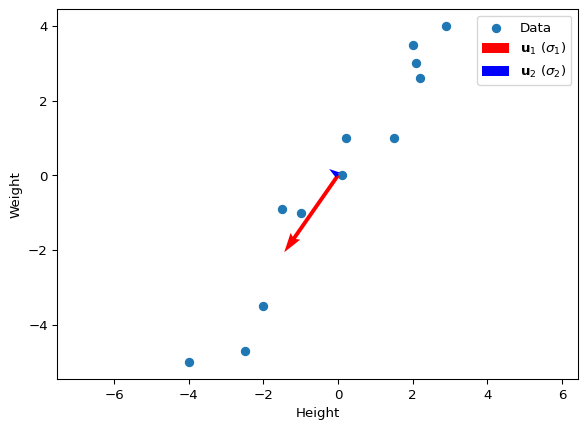

In [4]:
plt.clf()

plt.scatter(data.T[:,0], data.T[:,1], label='Data')
plt.quiver(0, 0, Ud[0,0]*Sd[0,0]/5, Ud[1,0]*Sd[0,0]/5, angles='xy', scale_units='xy', scale=1, color='red', label=r'$\mathbf{u}_1$ ($\sigma_1$)')
plt.quiver(0, 0, Ud[0,1]*Sd[1,1]/5, Ud[1,1]*Sd[1,1]/5, angles='xy', scale_units='xy', scale=1, color='blue', label=r'$\mathbf{u}_2$ ($\sigma_2$)')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.axis('equal')
plt.legend()
plt.show()

Typical interpretation:

-   $u_1$: height and weight increase together → overall **body size**
    direction.

-   $u_2$: height increases while weight decreases (or vice versa) →
    **body proportion** differences.

So $U$ provides an orthogonal coordinate system describing **how
measurements change**.

------------------------------------------------------------------------

## *The matrix $V$: patterns among people*

The matrix $V$ lives in **person space**.

Each column $v_i$ assigns a number to every person.

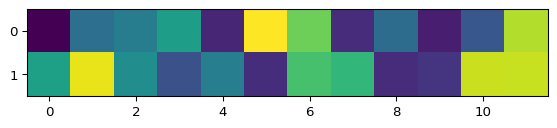

In [5]:
plt.clf()
plt.imshow(Vd.T[:2,:])
plt.show()

Each vector $v_i$ tells us:

> **which people participate in a particular pattern of variation.**

Interpretation:

-   Large positive entry → that person strongly follows the pattern.
-   Negative entry → participates in the opposite way.
-   Near zero → little involvement.

Examples:

-   The first pattern (in the first row) separates larger vs. smaller
    individuals.
-   The second pattern (in the second row) contrasts tall–light
    vs. short–heavy people.

Because measurements live in a 2-dimensional space (height and weight),
only **two independent population patterns** are needed.

------------------------------------------------------------------------

## *Reconstructing the data*

Using the first two rows of $V^T$, scaled by the singular values and
rotated by $U$:

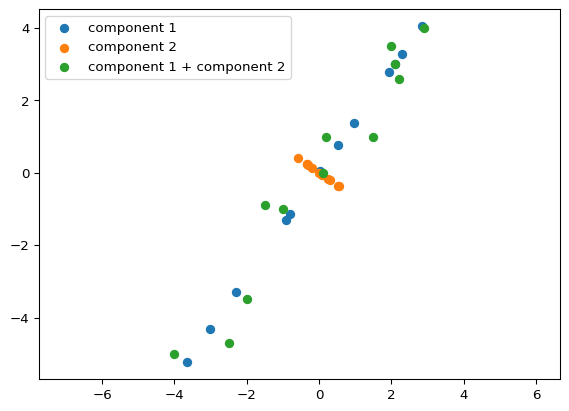

In [6]:
plt.clf()
component1 = np.outer(Vd.T[:,0],Sd[0,0]*Ud[0])
component2 = np.outer(Vd.T[:,1],Sd[1,1]*Ud[1])
plt.scatter(component1[:,0],component1[:,1])
plt.scatter(component2[:,0],component2[:,1])
combined = component1 + component2
plt.scatter(combined[:,0],combined[:,1])
plt.axis('equal')
plt.legend(["component 1", "component 2", "component 1 + component 2"])
plt.show()

Each term of the SVD

$$
A = U S V^\mathsf{T}
$$

can be written as

$$
A
=
\sigma_1 u_1 v_1^\mathsf{T}
+
\dots
+
\sigma_r u_r v_r^\mathsf{T}.
$$

Each component means:

-   $v_i$: how much this individual participates in the pattern,
-   $u_i$: how height and weight change,
-   $\sigma_i$: how important this pattern is.

------------------------------------------------------------------------

## *Skills*

-   Interpret the columns of $U$ as directions of change in measurement
    space.

-   Interpret the columns of $V$ as independent patterns among
    individuals.

-   Express the matrix as a sum of outer products
    $\sigma_i \mathbf{u}_i \mathbf{v}_i^T$. lls

-   Interpret the columns of $U$ as capturing relationships between rows
    of the data matrix

-   Interpret the rows of $V^T$ as capturing relationships between
    columns

-   Express the matrix as a sum of outer products
    $\sigma_i \mathbf{u}_i \mathbf{v}_i^T$

# *SVD on images*

SVD for image compression; left/right singular vectors; color images;
PCA as truncated SVD.

## *Motivation: a cat*

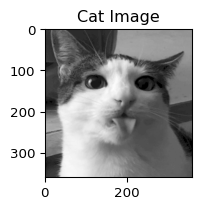

In [7]:
# display the path of the current python environment

import cv2

image = cv2.imread('test_cat.png', cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(2, 2))
plt.imshow(image, cmap='gray')
plt.title('Cat Image')
plt.show()

## *Dimensions of the decomposition*

What are the dimensions of the decompositions for an image?

In [8]:
U, S, Vt = np.linalg.svd(image, full_matrices=False)
print(f'The shape of U is {U.shape}, the shape of S is {S.shape}, the shape of V is {Vt.shape}')

The shape of U is (360, 360), the shape of S is (360,), the shape of V is (360, 360)

. . .

**Left singular values**, corresponding to U, are the eigenvalues of
$AA^T$. For an image, $AA^T$ is the covariance matrix of the rows of
$A$.

. . .

**Right singular values** are the eigenvalues of $A^{T}A$. For an image,
$A^TA$ is the covariance matrix of the columns of $A$.

## *Simple example*

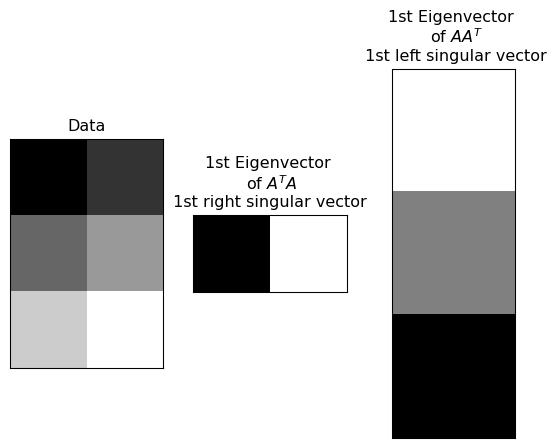

## *Reconstructing our matrix*

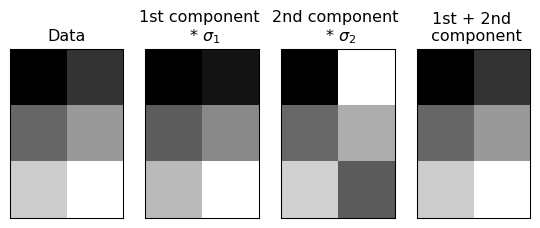

In [10]:
U, S, Vt = np.linalg.svd(A, full_matrices=False)
ax1 = plt.subplot(141)
ax2 = plt.subplot(142)
ax3 = plt.subplot(143)
ax4 = plt.subplot(144)
ax1.imshow(A, cmap='gray')
ax2.imshow(np.outer(U[:,0], Vt[0,:])*S[0], cmap='gray')
ax3.imshow(np.outer(U[:,1], Vt[1,:])*S[1], cmap='gray')
ax4.imshow(np.outer(U[:,0], Vt[0,:])*S[0]+np.outer(U[:,1], Vt[1,:])*S[1], cmap='gray')
for ax in [ax1, ax2, ax3,ax4]:
  ax.axes.xaxis.set_ticks([])
  ax.axes.yaxis.set_ticks([])
ax1.set_title('Data')
ax2.set_title('1st component \n * $\sigma_1$')
ax3.set_title('2nd component \n * $\sigma_2$')
ax4.set_title('1st + 2nd \n component')
plt.show()

How much of the variance is captured by the first two components?

The variance captured by each component is the sum of the squares of the
singular values divided by the sum of the squares of all the singular
values.

## *Back to the cat*

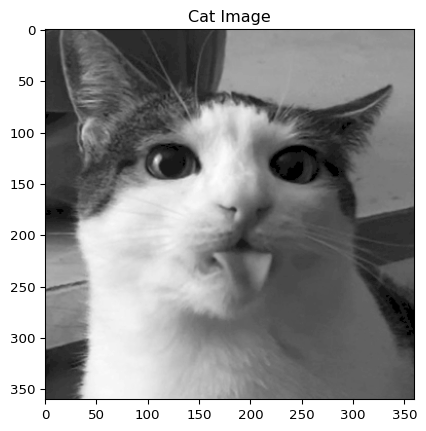

In [11]:
# !pip3 install opencv-python

plt.imshow(image, cmap='gray')
plt.title('Cat Image')
plt.show()

In [12]:
U, S, Vt = np.linalg.svd(image, full_matrices=False)

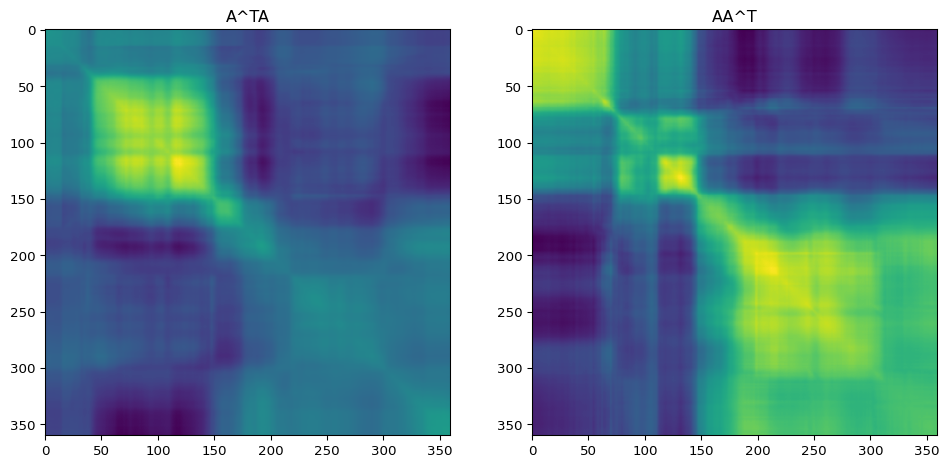

In [13]:
fig = plt.figure(figsize=(12, 6))
imsub = image-np.mean(image,axis=0)
imsub = imsub - np.mean(imsub,axis=1)
aat=imsub@imsub.T
ata=imsub.T@imsub
ax1=fig.add_subplot(121)
ax1.imshow(ata)


ax2=fig.add_subplot(122)
ax2.imshow(aat)
ax2.set_title("AA^T")
ax1.set_title("A^TA")
plt.show()

## *First Singular Value*

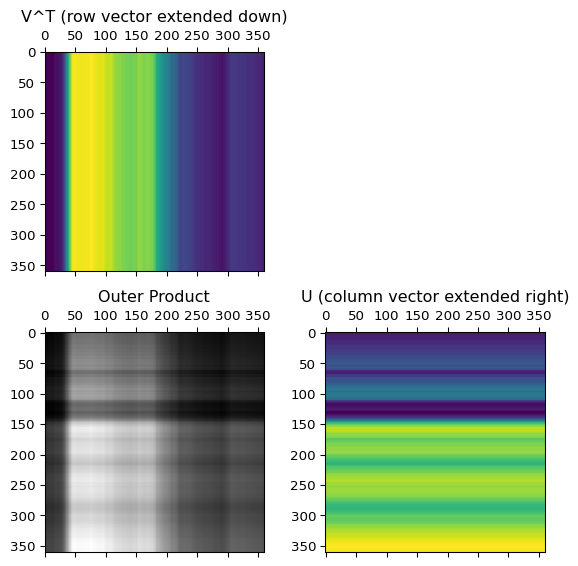

## *Second Singular Value*

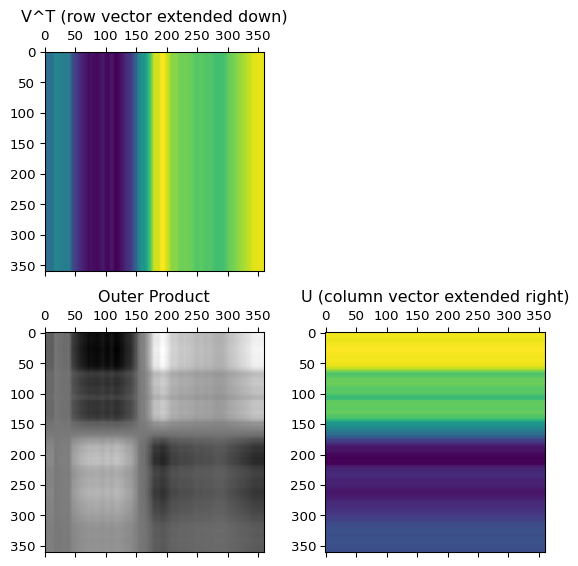

In [15]:
plot_uv(1)

## *Third Singular Value*

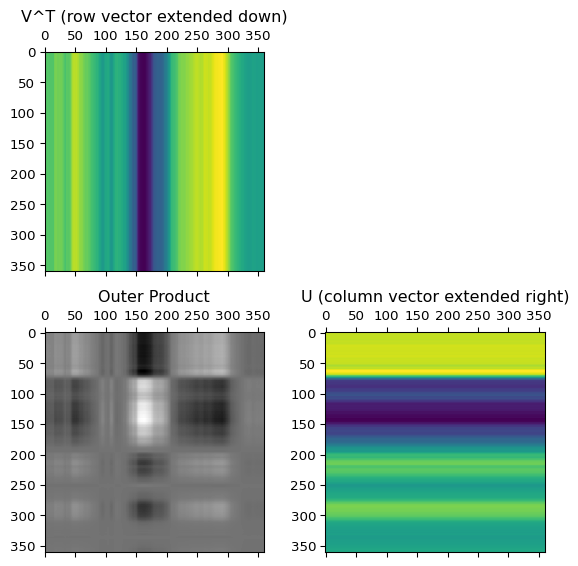

In [16]:
plot_uv(2)

## *Adding them up*

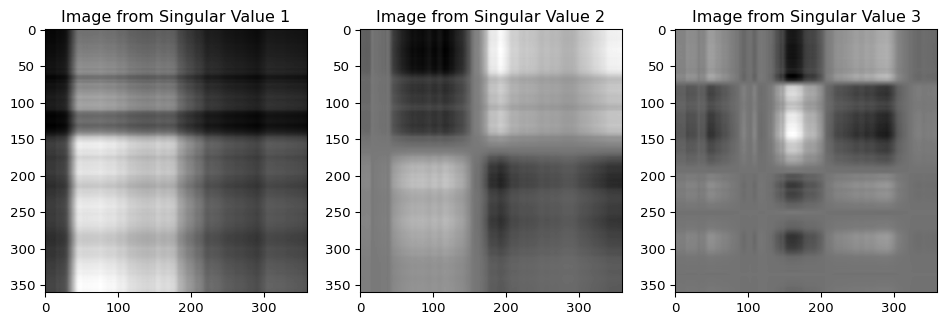

In [17]:
fig = plt.figure(figsize=(12, 6))
for i in range(3):
    reconstructed_image = np.matrix(U[:,i:i+1]) * np.diag(S[i:i+1]) * np.matrix(Vt[i:i+1,:])
    ax1 = fig.add_subplot(131+i)
    ax1.imshow(reconstructed_image, cmap='gray')
    ax1.set_title(f'Image from Singular Value {i+1}')
plt.show()

. . .

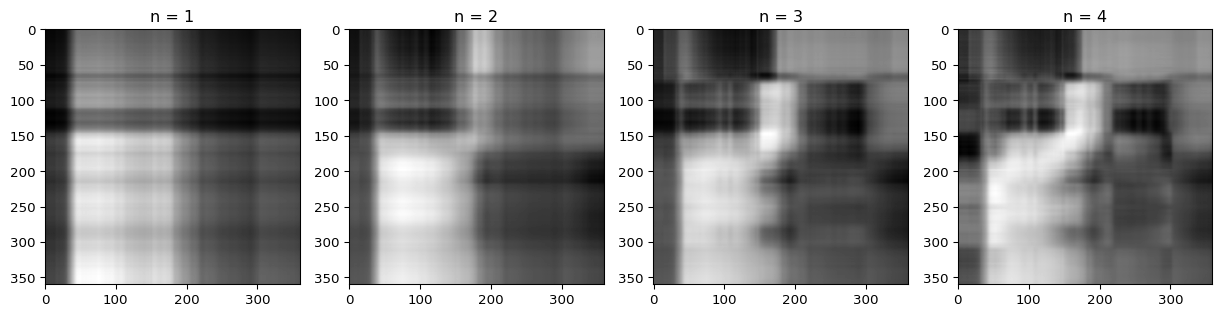

In [18]:
plt.figure(figsize=(16,4))

# start, end, step = 5, 25, 5
start, end, step = 1, 5, 1
for i in range(start, end, step):
    plt.subplot(1, (end - start) // step + 1, (i - start) // step + 1)
    reconstructed = np.matrix(U[:, :i]) * np.diag(S[:i]) * np.matrix(Vt[:i, :])
    plt.imshow(reconstructed, cmap='gray')
    plt.title('n = %s' % i)

plt.tight_layout()
plt.show()

##

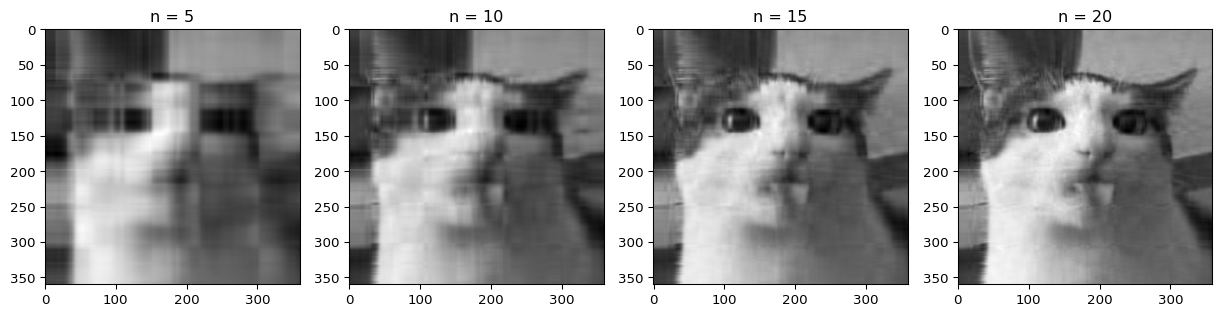

In [19]:
plt.figure(figsize=(16,4))

start, end, step = 5, 25, 5
#start, end, step = 1, 5, 1
for i in range(start, end, step):
    plt.subplot(1, (end - start) // step + 1, (i - start) // step + 1)
    reconstructed = np.matrix(U[:, :i]) * np.diag(S[:i]) * np.matrix(Vt[:i, :])
    plt.imshow(reconstructed, cmap='gray')
    plt.title('n = %s' % i)

plt.tight_layout()
plt.show()

## *Color images*

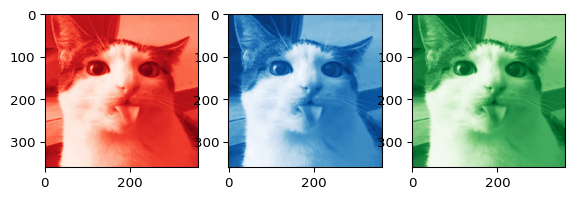

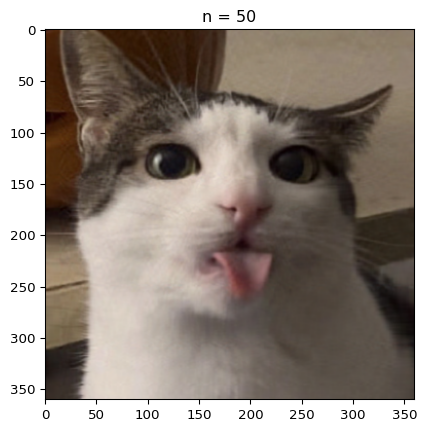

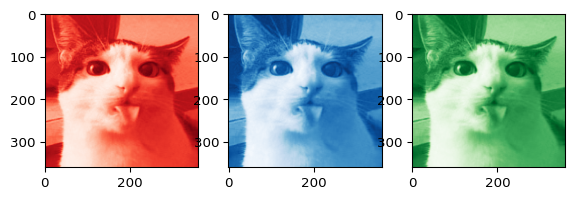

In [21]:
# SVD for each channel
U_R, S_R, Vt_R = np.linalg.svd(R, full_matrices=False)
U_G, S_G, Vt_G = np.linalg.svd(G, full_matrices=False)
U_B, S_B, Vt_B = np.linalg.svd(B, full_matrices=False)

n = 50  # rank approximation parameter
R_compressed = np.matrix(U_R[:, :n]) * np.diag(S_R[:n]) * np.matrix(Vt_R[:n, :])
G_compressed = np.matrix(U_G[:, :n]) * np.diag(S_G[:n]) * np.matrix(Vt_G[:n, :])
B_compressed = np.matrix(U_B[:, :n]) * np.diag(S_B[:n]) * np.matrix(Vt_B[:n, :])

# Combining the compressed channels
compressed_image = cv2.merge([np.clip(R_compressed, 1, 255), np.clip(G_compressed, 1, 255), np.clip(B_compressed, 1, 255)])
compressed_image = compressed_image.astype(np.uint8)
plt.imshow(compressed_image)
plt.title('n = %s' % n)
plt.show()

# Plotting the compressed RGB channels
plt.subplot(1, 3, 1)
plt.imshow(R_compressed, cmap='Reds_r')
plt.subplot(1, 3, 2)
plt.imshow(B_compressed, cmap='Blues_r')
plt.subplot(1, 3, 3)
plt.imshow(G_compressed, cmap='Greens_r')
plt.show()

## *How many singular values to keep?*

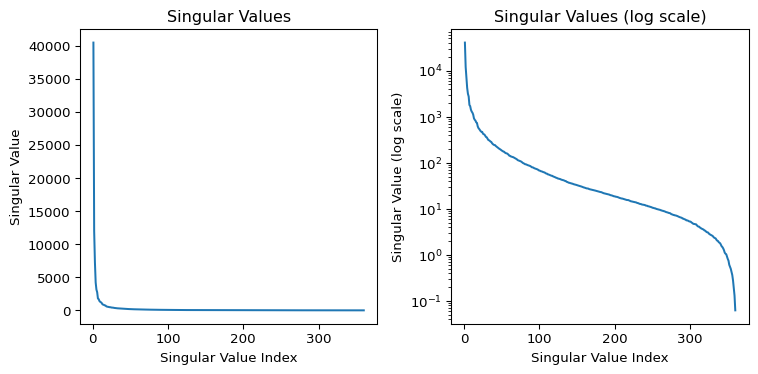

In [22]:
# Plotting the singular values
plt.figure(figsize=(8,4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(S) + 1), S)
plt.xlabel('Singular Value Index')
plt.ylabel('Singular Value')
plt.title('Singular Values')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(S) + 1), S)
plt.xlabel('Singular Value Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values (log scale)')
plt.yscale('log')

plt.tight_layout()
plt.show()

## *Different sorts of images*

Just plain noise:

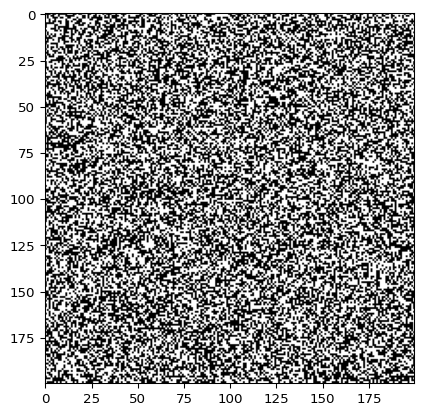

In [23]:
noise = np.random.randint(0,2,size=(200,200))
plt.imshow(noise, cmap='gray')

##

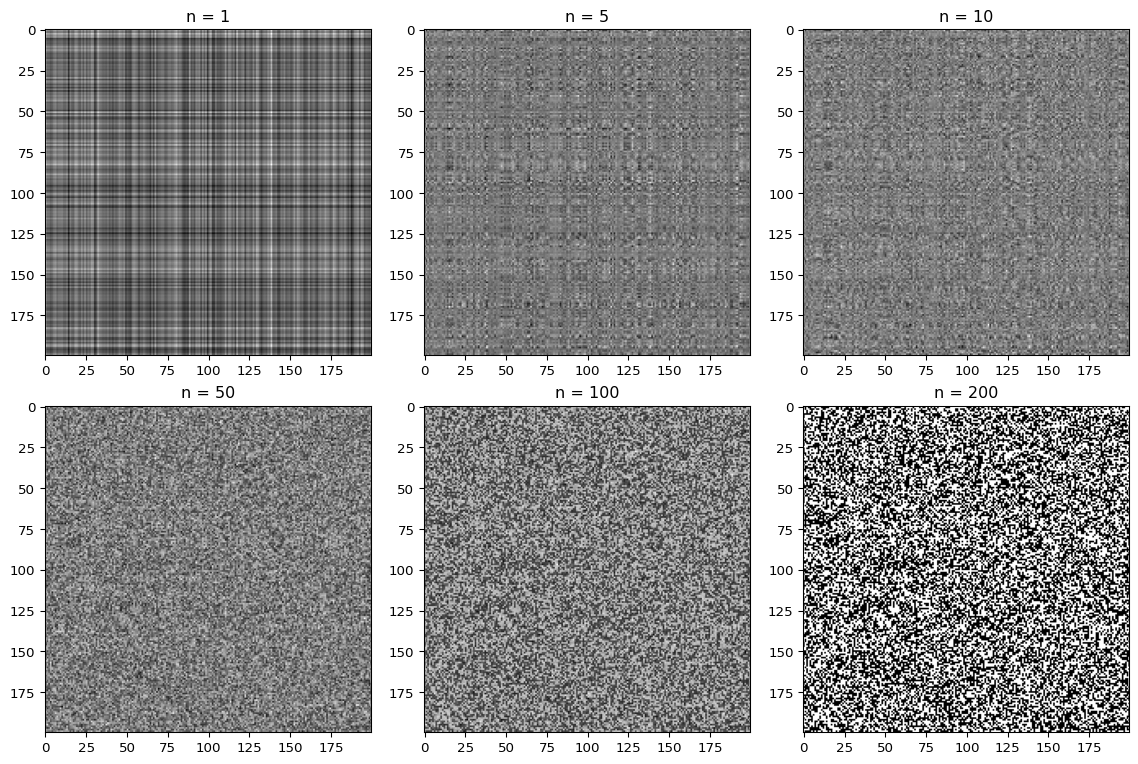

In [24]:
U_N, S_N, Vt_N = np.linalg.svd(noise, full_matrices=False)

# Plotting the compressed noise for different values of n
components = [1, 5, 10, 50, 100, 200]

fig = plt.figure(figsize=(12,8))

for i in range(len(components)):
    plt.subplot(2, 3, i+1)
    noise_compressed = np.matrix(U_N[:, :components[i]]) * np.diag(S_N[:components[i]]) * np.matrix(Vt_N[:components[i], :])
    plt.imshow(noise_compressed, cmap='gray')
    plt.title('n = %s' % components[i])

plt.tight_layout()
plt.show()

##

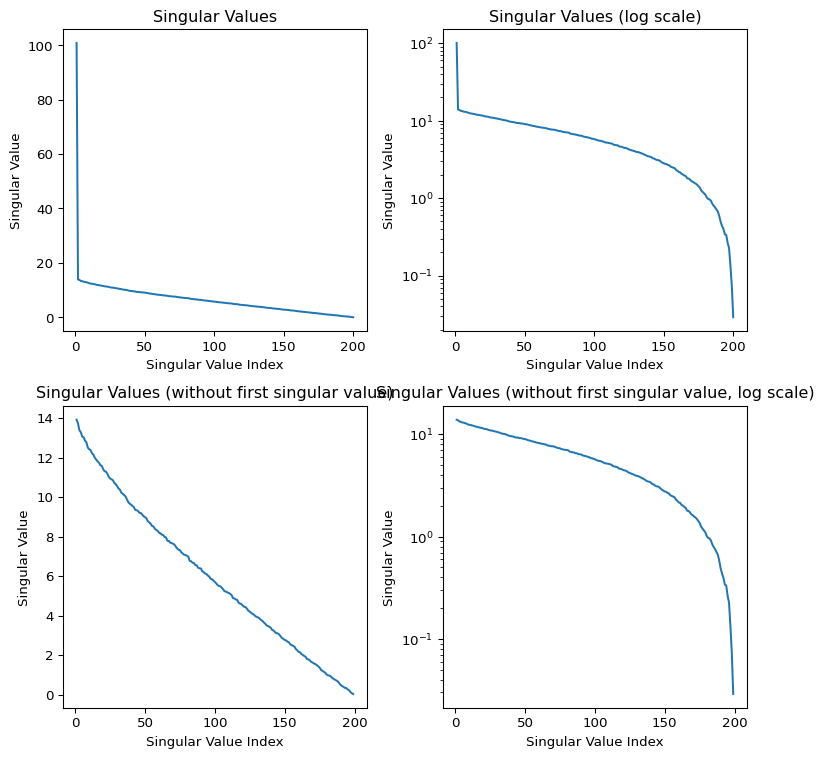

In [25]:
def plot_singular_values(S, title):
    plt.plot(range(1, len(S) + 1), S)
    plt.xlabel('Singular Value Index')
    plt.ylabel('Singular Value')
    plt.title(title)

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plot_singular_values(S_N, 'Singular Values')

plt.subplot(2, 2, 2)
plot_singular_values(S_N, 'Singular Values (log scale)')
plt.yscale('log')

plt.subplot(2, 2, 3)
plot_singular_values(S_N[1:], 'Singular Values (without first singular value)')

plt.subplot(2, 2, 4)
plot_singular_values(S_N[1:], 'Singular Values (without first singular value, log scale)')
plt.yscale('log')

plt.tight_layout()
plt.show()

## *Plaid shirt*

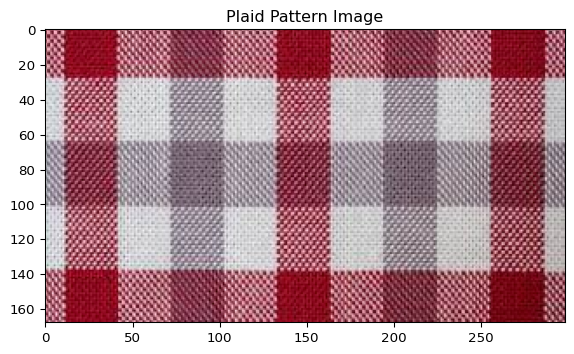

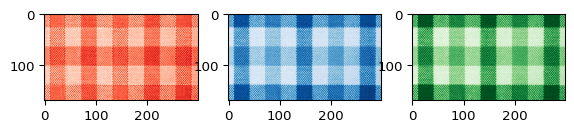

In [26]:
# Show plaid pattern image
plaid_image = cv2.imread('plaid_pattern.jpg')
plt.imshow(plaid_image[:,:,::-1])
plt.title('Plaid Pattern Image')
plt.show()

# Split the image into R, G, and B color channels
B, G, R = cv2.split(plaid_image)
plt.subplot(1, 3, 1)
plt.imshow(R, cmap='Reds_r')
plt.subplot(1, 3, 2)
plt.imshow(B, cmap='Blues_r')
plt.subplot(1, 3, 3)
plt.imshow(G, cmap='Greens_r')
plt.show()

##

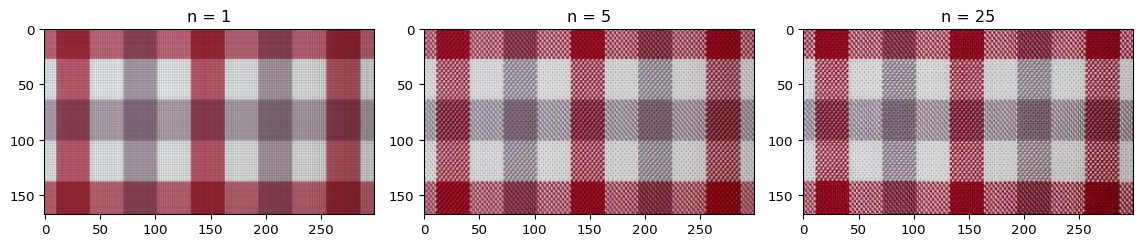

In [27]:
def rgb_approximation(R, G, B, n):
    U_R, S_R, Vt_R = np.linalg.svd(R, full_matrices=False)
    U_G, S_G, Vt_G = np.linalg.svd(G, full_matrices=False)
    U_B, S_B, Vt_B = np.linalg.svd(B, full_matrices=False)

    R_compressed = np.matrix(U_R[:, :n]) * np.diag(S_R[:n]) * np.matrix(Vt_R[:n, :])
    G_compressed = np.matrix(U_G[:, :n]) * np.diag(S_G[:n]) * np.matrix(Vt_G[:n, :])
    B_compressed = np.matrix(U_B[:, :n]) * np.diag(S_B[:n]) * np.matrix(Vt_B[:n, :])

    compressed_image = cv2.merge([np.clip(R_compressed, 1, 255), np.clip(G_compressed, 1, 255), np.clip(B_compressed, 1, 255)])
    compressed_image = compressed_image.astype(np.uint8)

    return compressed_image

n_values = [1, 5, 25]

plt.figure(figsize=(12, 6))
for i, n in enumerate(n_values):
    plt.subplot(1, len(n_values), i+1)
    plt.imshow(rgb_approximation(R, G, B, n))
    plt.title('n = %s' % n)

plt.tight_layout()
plt.show()

## *Singular values*

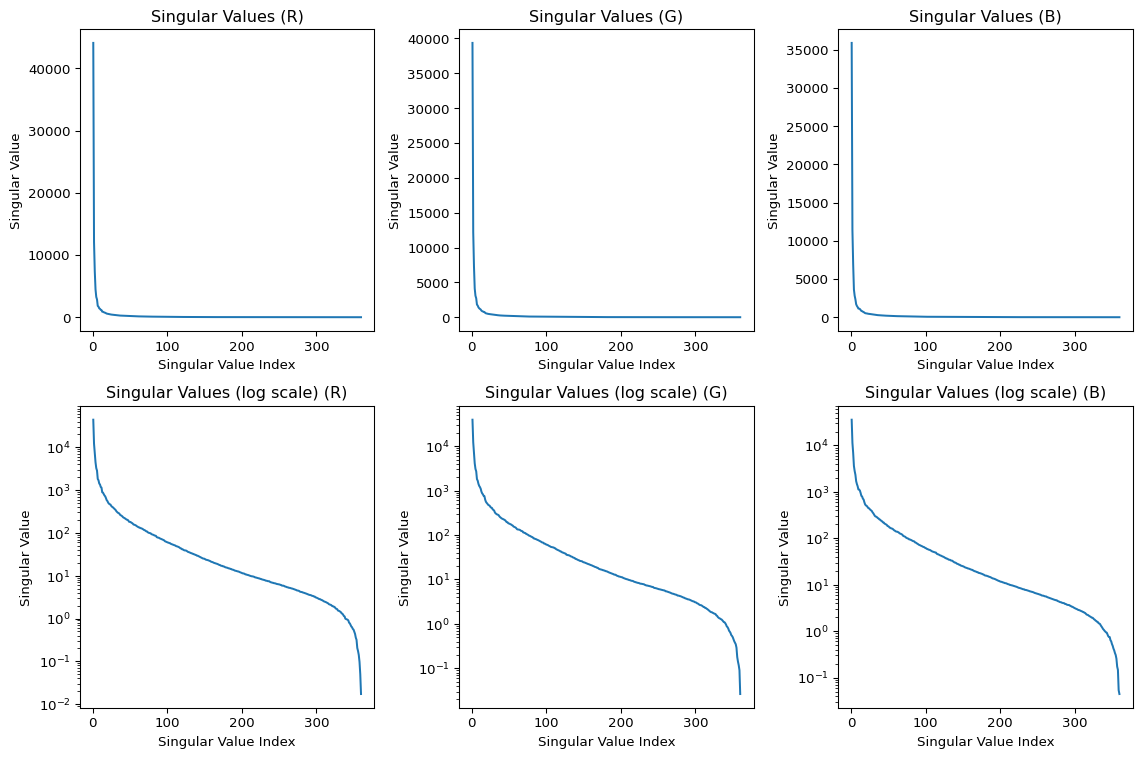

In [28]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plot_singular_values(S_R, 'Singular Values (R)')

plt.subplot(2, 3, 2)
plot_singular_values(S_G, 'Singular Values (G)')

plt.subplot(2, 3, 3)
plot_singular_values(S_B, 'Singular Values (B)')

plt.subplot(2, 3, 4)
plot_singular_values(S_R, 'Singular Values (log scale) (R)')
plt.yscale('log')

plt.subplot(2, 3, 5)
plot_singular_values(S_G, 'Singular Values (log scale) (G)')
plt.yscale('log')

plt.subplot(2, 3, 6)
plot_singular_values(S_B, 'Singular Values (log scale) (B)')
plt.yscale('log')

plt.tight_layout()
plt.show()

## *Individual components*

First component:

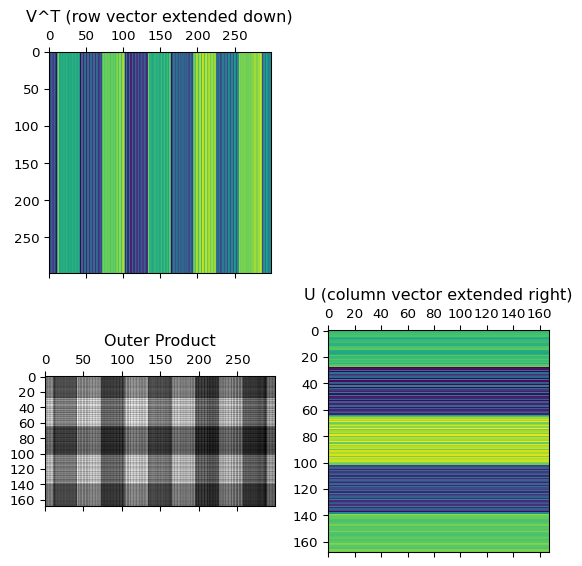

In [29]:
 U_R, S_R, Vt_R = np.linalg.svd(R, full_matrices=False)
plot_uv(0, U=U_R, S=S_R, Vt=Vt_R)

## 

Second component:

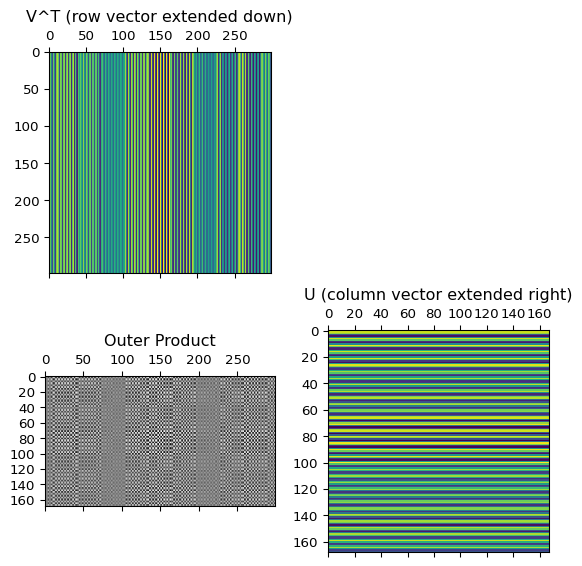

In [30]:
plot_uv(1, U=U_R, S=S_R, Vt=Vt_R)

## *Using “PCA” from sklearn*

This is just an easier way to implement taking these first few
components…

The shape of the image is (168, 299), and the shape of the compressed image is (168, 2)

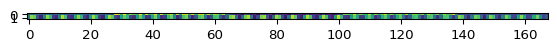

In [31]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(R) # fit the model -- compute the matrices
transformed = pca.transform(R) # transform the data
print(f'The shape of the image is {R.shape}, and the shape of the compressed image is {transformed.shape}')
plt.imshow(transformed.T)

. . .

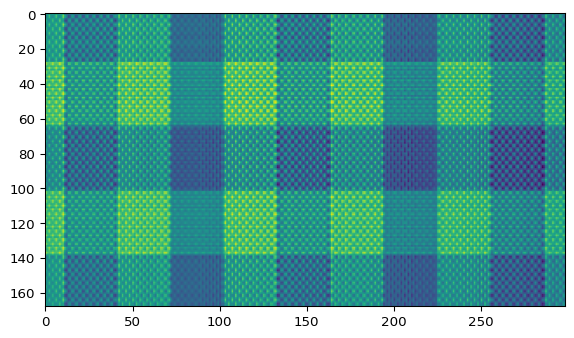

In [32]:
plt.imshow(pca.inverse_transform(transformed))

## 

Try adding noise…

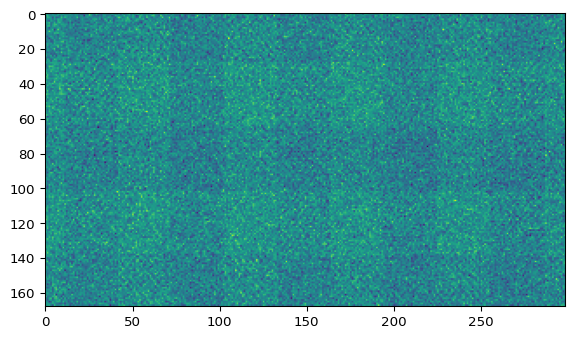

In [33]:
alpha = 10
R_noisy = R + np.random.normal(0, 10, R.shape)*alpha
plt.imshow(R_noisy)

Now clean it up with PCA:

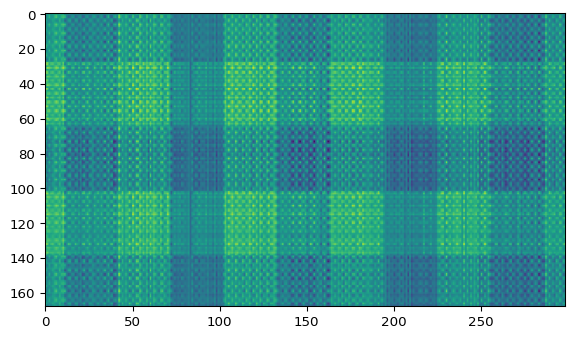

In [34]:
pca = PCA(n_components=2)
pca.fit(R_noisy)
plt.imshow(pca.inverse_transform(pca.transform(R_noisy)))

## *Skills*

-   Compute the SVD of an image matrix and interpret $U$, $S$, $V$
-   Reconstruct an image from the first $n$ singular value components
-   Apply SVD to color images (per channel)
-   Use PCA as a convenient truncated SVD; interpret variance captured

# *SVD in higher dimensions*

PCA on high-dimensional data (faces); low-rank reconstruction;
connection to SVD.

## *Faces*

The shape of the faces dataset is (1348, 62, 47)

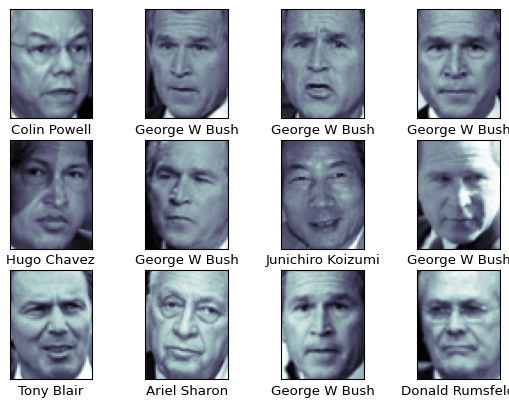

In [35]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=60)


# display a few of the faces, along with their names
fig, ax = plt.subplots(3, 4)
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]]) 

print(f'The shape of the faces dataset is {faces.images.shape}')

## *PCA on faces*

In [36]:
pca = PCA(150, svd_solver='randomized', random_state=42)
pca_small = PCA(10, svd_solver='randomized', random_state=42)
pca_very_small = PCA(2, svd_solver='randomized', random_state=42)
pca.fit(faces.data)
pca_small.fit(faces.data)
pca_very_small.fit(faces.data)

PCA(n_components=2, random_state=42, svd_solver='randomized') In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook. On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org. PCA PCA(n_components=2, random_state=42, svd_solver='randomized')

This treatment from
[here](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/05.09-Principal-Component-Analysis.ipynb)

. . .

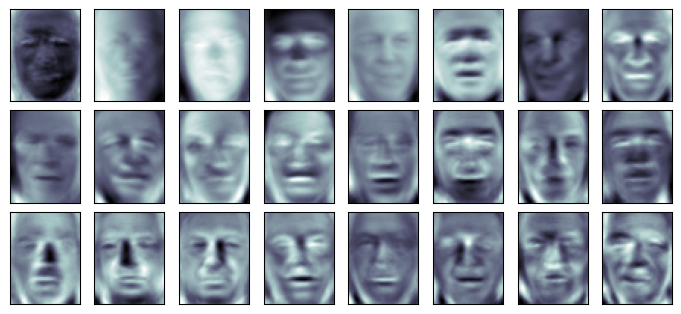

In [37]:
fig, axes = plt.subplots(3, 8, figsize=(9, 4),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(62, 47), cmap='bone')

## *Reconstructions*

In [38]:
# Compute the components and projected faces
pca = pca.fit(faces.data)
components = pca.transform(faces.data)
projected = pca.inverse_transform(components)

components_small = pca_small.transform(faces.data)
projected_small = pca_small.inverse_transform(components_small)


components_very_small = pca_very_small.transform(faces.data)
projected_very_small = pca_very_small.inverse_transform(components_very_small)

##

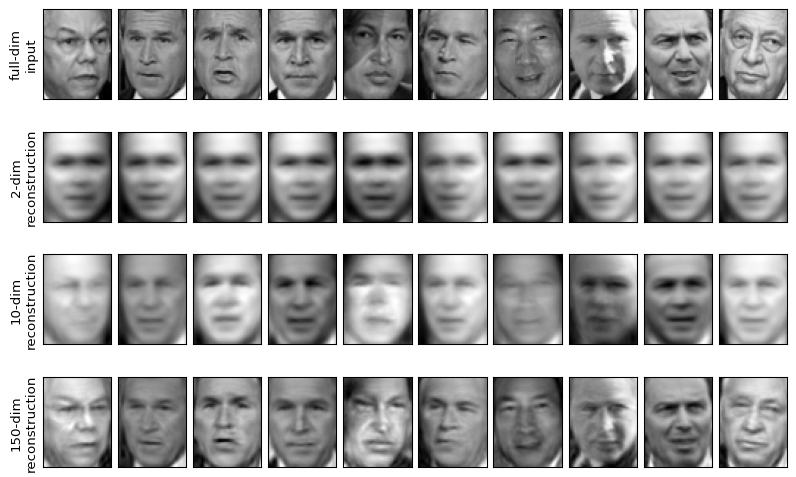

In [39]:
# Plot the results
fig, ax = plt.subplots(4, 10, figsize=(10, 6.5),
                       subplot_kw={'xticks':[], 'yticks':[]},
                       gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i in range(10):
    ax[0, i].imshow(faces.data[i].reshape(62, 47), cmap='binary_r')
    ax[1, i].imshow(projected_very_small[i].reshape(62, 47), cmap='binary_r')
    ax[2, i].imshow(projected_small[i].reshape(62, 47), cmap='binary_r')
    ax[3, i].imshow(projected[i].reshape(62, 47), cmap='binary_r')
    
ax[0, 0].set_ylabel('full-dim\ninput')
ax[1, 0].set_ylabel('2-dim\nreconstruction');
ax[2, 0].set_ylabel('10-dim\nreconstruction');
ax[3, 0].set_ylabel('150-dim\nreconstruction');

## 

Really cool demo of SVD image compression:
https://timbaumann.info/svd-image-compression-demo/

## *Skills*

-   Apply PCA to high-dimensional data (e.g., faces) and interpret
    components
-   Reconstruct data from a low-rank PCA approximation
-   Recognize PCA as truncated SVD on mean-centered data

## *Now you*

Code up your own image compression using SVD and show the left and right
singular vectors, the singular values, and the reconstructed images.

Share with the class!